# Chapter 5: What the Model Becomes Inside an Agent

The model chooses an action, but the tool determines what that action does. Changing the tool can therefore change the assembled agent while the chooser stays fixed. The same applies to memory, observations, and recurrence: the model is one factor in a stochastic system, not the whole system boundary.

This notebook composes a small chooser matrix with a tool matrix and follows the resulting state distribution over repeated transitions. Beside that kernel experiment, it compares two reliability constructions with identical marginal step success. One has independent step outcomes; the other has a single shared good-or-bad condition. Their disagreement makes a practical point: multiplying average step rates is not justified merely because the averages look reassuring.

**Outcome:** Compose a chooser and tool kernel, then separate marginal from trajectory reliability.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let C(i,a) be the chooser probability of action a in state i, and T(a,j) the tool probability of next state j after that action. The composed kernel is K(i,j)=sum_a C(i,a)T(a,j). Its rows sum to one when both factors are normalized. A row-vector state distribution evolves as mu_(t+1)=mu_t K.

This finite factorization deliberately omits state-dependent tool effects beyond the declared action encoding. To model them, enlarge the state/action representation rather than silently crediting the chooser with tool behavior. The changed tool kernel leaves C fixed, so any distributional difference is attributable to that controlled factor change inside this construction.

For reliability, independent equal-probability steps give P(all n succeed)=p^n. A shared condition that makes every step succeed together with probability p gives P(all n succeed)=p. Both have marginal step success p. The general chain rule is the product of conditional probabilities P(S_t|S_1,...,S_(t-1)); supplied marginals are not those conditionals.

The conditional_success vector is therefore a separate input. Its product describes its own declared trajectory law and need not have the same length or dependence structure as the plotted equal-step cases. None of these constructed distributions predicts a real agent without corresponding evidence.

The assembly comparison makes the remaining system factors explicit. O maps state to observed context; M maps observed context through the declared memory transform; R applies the retrieval transform; C is the same frozen chooser; T supplies the tool effect. The assembly kernel is O M R C T. Every row-stochastic product remains row stochastic. These finite maps are a construction, not a representation learned from documents. The state and context encoding must contain whatever history matters for the intended Markov boundary.

## Apply this to an agent

Use the composed kernel to describe the agent built around the same frozen model. Compare memory, retrieval and tool assemblies, then distinguish a step success rate from the probability that the complete workflow succeeds.

## A calculation you can run

Supply normalized chooser rows, normalized tool rows, and an initial state distribution. The chooser's action dimension must match the tool's row count, and the tool's next-state dimension must match the chooser's state count. The function multiplies the factors, then propagates the initial distribution for the declared number of steps.

The state-zero occupancy chart shows recurrence under the composite kernel. The two reliability charts use transition count on the horizontal axis and all-step success probability on the vertical axis. They are separate constructions, not estimates from the occupancy curve. Change the tool matrix while keeping the chooser fixed, then compare terminal state distributions. Use the explicit conditional vector to check the chain rule independently by hand.

Compare five assemblies: complete context, blurred memory, blurred retrieval, blurred observation, and a single-transition controller. Their declared resource allowances match in the default case. A blurred map sends either context to the same equal mixture, erasing its distinction before the fixed chooser acts. The recurrence comparison changes transition count while reserving the same allowance; it does not claim equal consumed work. Read assembly_budgets_matched and assembly_depths_matched before attributing an observed difference to one factor. The transfer case deliberately breaks budget equality.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 5
inputs = {'step_success': 0.99,
 'steps': 100,
 'conditional_success': [0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99],
 'chooser': [[0.8, 0.2], [0.3, 0.7]],
 'tool': [[0.9, 0.1], [0.2, 0.8]],
 'initial': [1, 0],
 'assemblies': [{'name': 'complete',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.9, 0.1], [0.2, 0.8]]},
                {'name': 'memory blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[0.5, 0.5], [0.5, 0.5]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.9, 0.1], [0.2, 0.8]]},
                {'name': 'retrieval blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[0.5, 0.5], [0.5, 0.5]],
                 'tool': [[0.9, 0.1], [0.2, 0.8]]},
                {'name': 'observation blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[0.5, 0.5], [0.5, 0.5]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.9, 0.1], [0.2, 0.8]]},
                {'name': 'single transition',
                 'budget': 100,
                 'steps': 1,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.9, 0.1], [0.2, 0.8]]}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 5: composite-kernel
What system does a frozen chooser become when its surrounding kernel changes?
Evidence: constructed teaching example

Calculated quantities:
{
  "assemblies": [
    {
      "assembly": "complete",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.76,
          0.24
        ],
        [
          0.41,
          0.59
        ]
      ],
      "terminal_distribution": [
        0.6307794162,
        0.3692205838
      ]
    },
    {
      "assembly": "memory blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.585,
          0.415
        ],
        [
          0.585,
          0.415
        ]
      ],
      "terminal_distribution": [
        0.585,
        0.415
      ]
    },
    {
      "assembly": "retrieval blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.585,
          0.415
        ],
        [
          0.585,
          0.415
        ]
     

With p=0.99 and n=100, independent all-step success is about 0.366. Under the shared condition, all-step success is 0.99. The per-step marginals are identical. That contrast rules out treating a marginal success rate as enough information to determine long-run completion.

The default composed first row is [0.76,0.24]: action-zero contribution is 0.8 times [0.9,0.1], and action-one contribution is 0.2 times [0.2,0.8]. In the changed case this row becomes [0.50,0.50] because only the tool factor changes. The frozen chooser now participates in a different recurrent system, even though its own probabilities are unchanged.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


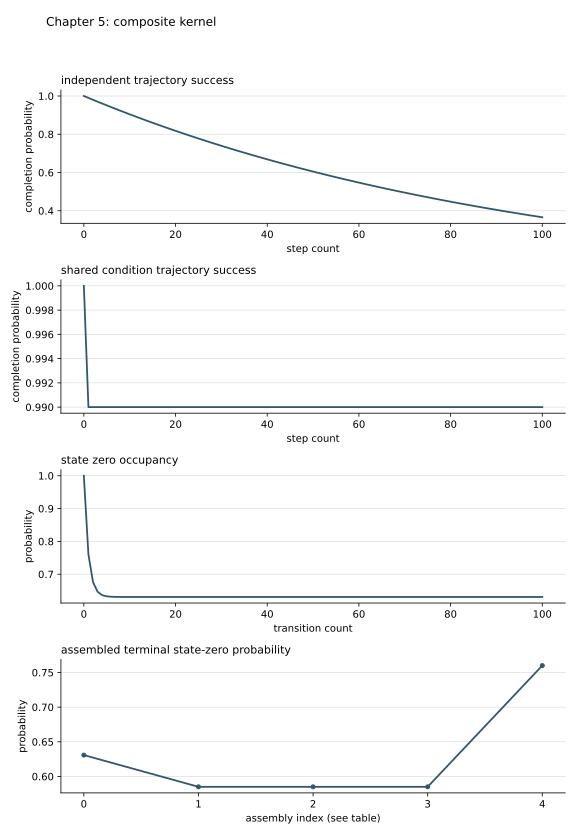

In [3]:
display(SVG(figure_svg(report)))

**Figure 5.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A product of marginal rates can be exact in an independent construction and seriously wrong under shared failures. It can also be pessimistic when the workflow detects, retries, or recovers from errors. This notebook does not include recovery, so its all-step event should not be renamed authorized confirmed terminal completion.

A composite kernel can also fail through a state boundary that omits information needed for the next transition. If memory version or tool state affects outcomes, but neither appears in the current state, the supplied kernel may not describe a Markov process. Adding more recurrence iterations will not repair that omission.

The changed case is a controlled mechanism experiment, not a fitted explanation of empirical behavior. Real ablations need matched budgets, observations, and task populations. Preserve those conditions before claiming that one surrounding component accounts for measured agent improvement.

The optional assembly table supplies observation, memory and retrieval ablations alongside recurrence. A changed terminal distribution identifies the consequence of the stipulated map within this construction. It does not show that a real memory or retrieval mechanism has the same effect. Different budgets or transition depths change the comparison contract and must be reported; the transfer table exposes a mismatched budget.

Chapter 5: composite-kernel
What system does a frozen chooser become when its surrounding kernel changes?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "assemblies": [
    {
      "assembly": "complete",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.5,
          0.5
        ],
        [
          0.25,
          0.75
        ]
      ],
      "terminal_distribution": [
        0.3333339691,
        0.6666660309
      ]
    },
    {
      "assembly": "memory blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.375,
          0.625
        ],
        [
          0.375,
          0.625
        ]
      ],
      "terminal_distribution": [
        0.375,
        0.625
      ]
    },
    {
      "assembly": "retrieval blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.375,
          0.625
        ],
        [
          0.375,
          0.625
       

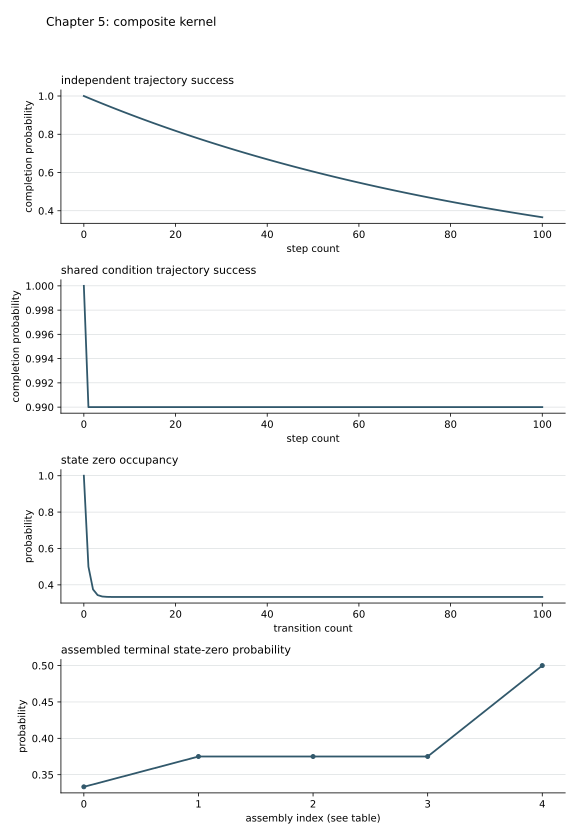

In [4]:
changed_inputs = {'step_success': 0.99,
 'steps': 100,
 'conditional_success': [0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99],
 'chooser': [[0.8, 0.2], [0.3, 0.7]],
 'tool': [[0.6, 0.4], [0.1, 0.9]],
 'initial': [1, 0],
 'assemblies': [{'name': 'complete',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.6, 0.4], [0.1, 0.9]]},
                {'name': 'memory blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[0.5, 0.5], [0.5, 0.5]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.6, 0.4], [0.1, 0.9]]},
                {'name': 'retrieval blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[0.5, 0.5], [0.5, 0.5]],
                 'tool': [[0.6, 0.4], [0.1, 0.9]]},
                {'name': 'observation blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[0.5, 0.5], [0.5, 0.5]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.6, 0.4], [0.1, 0.9]]},
                {'name': 'single transition',
                 'budget': 100,
                 'steps': 1,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.6, 0.4], [0.1, 0.9]]}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 5.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case uses three conditional probabilities 0.9,0.8,0.7. Their chain-rule product is 0.504. The equal marginal independent construction gives 0.9^3=0.729, while the shared construction gives 0.9. They answer different distributional questions.

For a local controller, specify the complete state sufficient for one transition, then identify the chooser and effect boundary. If data provide only run-level completions, route them to the evaluation method instead of manufacturing a step kernel. If they provide uncertain tool acknowledgements, use an effect trace. The right reliability calculation follows the available evidence, not the presence of a convenient average.

In [5]:
transfer_inputs = {'step_success': 0.9,
 'steps': 3,
 'conditional_success': [0.9, 0.8, 0.7],
 'chooser': [[1, 0], [0, 1]],
 'tool': [[0.7, 0.3], [0.4, 0.6]],
 'initial': [0.5, 0.5],
 'assemblies': [{'name': 'complete',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.7, 0.3], [0.4, 0.6]]},
                {'name': 'memory blurred',
                 'budget': 120,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[0.5, 0.5], [0.5, 0.5]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.7, 0.3], [0.4, 0.6]]},
                {'name': 'retrieval blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[0.5, 0.5], [0.5, 0.5]],
                 'tool': [[0.7, 0.3], [0.4, 0.6]]},
                {'name': 'observation blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[0.5, 0.5], [0.5, 0.5]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.7, 0.3], [0.4, 0.6]]},
                {'name': 'single transition',
                 'budget': 100,
                 'steps': 1,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.7, 0.3], [0.4, 0.6]]}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 5: composite-kernel
What system does a frozen chooser become when its surrounding kernel changes?
Evidence: constructed transfer example

Calculated quantities:
{
  "assemblies": [
    {
      "assembly": "complete",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.7,
          0.3
        ],
        [
          0.4,
          0.6
        ]
      ],
      "terminal_distribution": [
        0.5714281496,
        0.4285718503
      ]
    },
    {
      "assembly": "memory blurred",
      "budget": 120.0,
      "steps": 10,
      "kernel": [
        [
          0.55,
          0.45
        ],
        [
          0.55,
          0.45
        ]
      ],
      "terminal_distribution": [
        0.55,
        0.45
      ]
    },
    {
      "assembly": "retrieval blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.55,
          0.45
        ],
        [
          0.55,
          0.45
        ]
      ],
      "ter

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **step_success:** Marginal equal-step probability in [0,1] for separate constructed reliability cases.
- **steps:** Positive integer transition count up to 1000.
- **conditional_success:** List of probabilities conditioned on all previous steps succeeding, one per step; its length must equal steps.
- **chooser:** State by action row-stochastic matrix.
- **tool:** Action by next-state row-stochastic matrix.
- **initial:** Normalized state distribution matching the composed kernel.
- **assemblies:** Optional rows with name,budget,steps,observation,memory,retrieval,tool. Context maps are square stochastic matrices in the declared context encoding. Chooser stays fixed. Resource allowances must share units; actual consumed work is not measured.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch05.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 5: composite-kernel
What system does a frozen chooser become when its surrounding kernel changes?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "assemblies": [
    {
      "assembly": "complete",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.7,
          0.3
        ],
        [
          0.4,
          0.6
        ]
      ],
      "terminal_distribution": [
        0.5714281496,
        0.4285718503
      ]
    },
    {
      "assembly": "memory blurred",
      "budget": 120.0,
      "steps": 10,
      "kernel": [
        [
          0.55,
          0.45
        ],
        [
          0.55,
          0.45
        ]
      ],
      "terminal_distribution": [
        0.55,
        0.45
      ]
    },
    {
      "assembly": "retrieval blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.55,
          0.45
        ],
        [
          0.55,
          0.

## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c05-d01"></a>

### Demonstration 1: Six assemblies around one frozen model

If the model never changes, how can six assemblies of it succeed at different rates, and what does the budget have to do with it?

![Equation un-numbered display 1](../assets/math/788eb3973bb881ecf8ff.svg)

![Equation 5.1](../assets/math/5f46914d9ff9a53d8e15.svg)

**Symbols and units:** A blind call is a model call that has not seen the tool's result. Its request probability is the share of blind calls that output request instead of an answer; the rest is split equally between the two answers. The hidden bit Y is 0 or 1 with equal chance. The tool reports Y correctly with probability 0.90. In a context that contains the report, the model answers with the reported bit with probability 0.85, with the other bit with probability 0.10, and outputs request with probability 0.05. A success is a correct final answer. In the state x_t = (c_t, m_t, w_t, b_t), c is the context the model sees, m the retained memory, w the world and b the remaining budget; here b is the number of calls left.

A blind answer is right about as often as it is wrong, whatever the hidden bit. Rows 2 and 3 add a memory and a tool, but no later call reads their output, so they cannot move the score; the stacked bars show that no part of their runs is rescued after the request. Row 4 adds a second blind call and row 5 an informed one, so both gain only through the requests they rescue. Row 6 is row 5 with one grant revoked. Memory is what row 2 supplies, the world is what the tool reads in row 5, and the budget is what pays for row 4's second call: with one call allowed, every row falls to the blind rate.

**Use in this chapter:** When someone says an agent is better because it has memory or tools, ask which later decision reads their output. A component that sits on no path from the model's output to the outcome contributes exactly zero.

**Assumptions:** At most two model calls, a tool that is either granted or denied, and the response laws above, which hold in every row. The six bars are assembly comparisons, not a matched factorial design: row 5 also adds recurrence, so the rows do not identify a memory and tool interaction. The rejection rule matters: if denial sends the run to a second blind call, row 6 equals row 4, not row 1. Nothing here says deployed effect sizes look like these. The one-call state is the chapter's own rule (a request on the last call terminates) applied to a smaller budget.

**Predict before running:** Leave the request probability at 0.40 and change denial to a second blind call. Which bar moves, and to what value?

**Controls you can change:**

- **Share of blind calls that output request:** `request` accepts 0.2, 0.4, 0.6.
- **What a denied request does:** `rejection` accepts 'stop', 'blind'.
- **Calls allowed in a run:** `calls` accepts 2, 1.

**Source section:** The fair experiment.

**Evidence:** constructed teaching example.

Constructed example: the chapter's six-assembly experiment; the default 0.40 request probability gives the book's values 0.30, 0.42 and 0.61.

Prediction choices:

1. Row 6 rises from 0.300 to 0.420, the value of row 4
2. Row 5 falls from 0.610 to 0.420
3. No bar moves, because denial removes the tool either way

**Boundary of the conclusion:** The six assemblies are teaching numbers, illustrative rather than a measurement of any deployed system. The size of the jump in row 5 is a modeling choice, made large because the argument is easier to see at full strength.

**Common wrong turn:** Storage nobody reads adds nothing, a tool nobody calls adds nothing, and a tool whose result never reaches a decision adds nothing. Rows 2 and 3 contain real, correctly built components that contribute exactly zero because they sit on no path from the model's output to the outcome.

Six assemblies around one frozen model
Controls: {"request": 0.4, "rejection": "stop", "calls": 2}
Evidence: constructed teaching example

Calculated quantities:
Model only: 0.300
Memory, no reader: 0.300
Tool, no recurrence: 0.300
Recurrence, blind: 0.420
Connected, granted: 0.610
Connected, denied: 0.300
Row 5 minus row 1: 0.310
Row 5 wrong answer: 0.370
Row 5 stops with no answer: 0.020
Calls allowed: 2

Worked steps:
1. Blind call: answer 0 and answer 1 each have probability (1 - 0.40) / 2 = 0.300; request has 0.40.
2. Either answer is right half the time, so a blind answer is correct with probability 0.300.
3. Row 4: the request starts a second blind call: 0.300 + 0.40 x 0.300 = 0.420.
4. Informed answer: 0.90 x 0.85 + 0.10 x 0.10 = 0.775; row 5 = 0.300 + 0.40 x 0.775 = 0.610.
5. Rows 1 to 3 cannot rescue a request, so each scores 0.300; row 6 is row 5 with the grant revoked.

A blind answer is correct with probability (1 - 0.40) / 2 = 0.300, whatever the hidden bit is. Row 4 = 0.

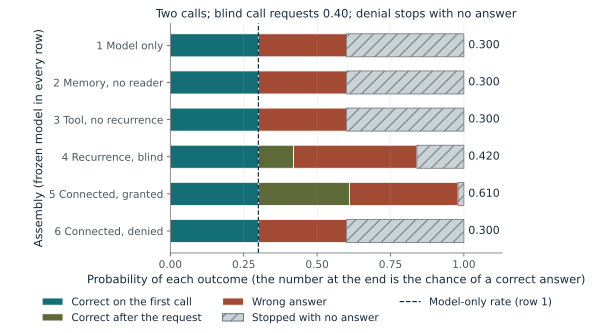

In [8]:
demo_id = 'C05-D01'
demo_controls = {'request': 0.4, 'rejection': 'stop', 'calls': 2}
demo_result = run_demo(5, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Share of blind calls that output request** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Six assemblies around one frozen model
Controls: {"request": 0.2, "rejection": "stop", "calls": 2}
Evidence: constructed teaching example

Calculated quantities:
Model only: 0.400
Memory, no reader: 0.400
Tool, no recurrence: 0.400
Recurrence, blind: 0.480
Connected, granted: 0.555
Connected, denied: 0.400
Row 5 minus row 1: 0.155
Row 5 wrong answer: 0.435
Row 5 stops with no answer: 0.010
Calls allowed: 2

Worked steps:
1. Blind call: answer 0 and answer 1 each have probability (1 - 0.20) / 2 = 0.400; request has 0.20.
2. Either answer is right half the time, so a blind answer is correct with probability 0.400.
3. Row 4: the request starts a second blind call: 0.400 + 0.20 x 0.400 = 0.480.
4. Informed answer: 0.90 x 0.85 + 0.10 x 0.10 = 0.775; row 5 = 0.400 + 0.20 x 0.775 = 0.555.
5. Rows 1 to 3 cannot rescue a request, so each scores 0.400; row 6 is row 5 with the grant revoked.

A blind answer is correct with probability (1 - 0.20) / 2 = 0.400, whatever the hidden bit is. Row 4 = 0.

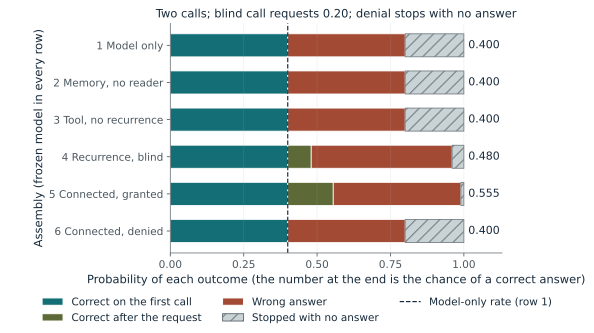

In [9]:
changed_controls = {'request': 0.2, 'rejection': 'stop', 'calls': 2}
changed_demo = run_demo(5, 'C05-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(5, 'C05-D01'):
    state = run_demo(5, 'C05-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "request": 0.2,
      "rejection": "stop",
      "calls": 2
    },
    "metrics": [
      [
        "Model only",
        "0.400"
      ],
      [
        "Memory, no reader",
        "0.400"
      ],
      [
        "Tool, no recurrence",
        "0.400"
      ],
      [
        "Recurrence, blind",
        "0.480"
      ],
      [
        "Connected, granted",
        "0.555"
      ],
      [
        "Connected, denied",
        "0.400"
      ],
      [
        "Row 5 minus row 1",
        "0.155"
      ],
      [
        "Row 5 wrong answer",
        "0.435"
      ],
      [
        "Row 5 stops with no answer",
        "0.010"
      ],
      [
        "Calls allowed",
        "2"
      ]
    ]
  },
  {
    "controls": {
      "request": 0.2,
      "rejection": "stop",
      "calls": 1
    },
    "metrics": [
      [
        "Model only",
        "0.400"
      ],
      [
        "Memory, no reader",
        "0.400"
      ],
      [
        "Tool, no rec

**Check your understanding:** If a blind call requested 0.60 of the time, what would the fully connected assembly (row 5) score?

[Answer and worked reasoning](../solutions/ch05.md#demonstration-1). [Matching browser demonstration](../readers/05-composite-kernel/reader.html#C05-D01).

<a id="demo-c05-d02"></a>

### Demonstration 2: A fixed chooser, a different tool, a different system

If the chooser's probabilities never change, can changing only the tool change where the system spends its time?

![Equation 5.2](../assets/math/d730604202b83b1f70fe.svg)

**Symbols and units:** A state is one of two constructed states, 0 and 1, standing for coarsened values of the agent's full state. The chooser row for state i gives the probability of each proposed action (the role of pi in the equation). The tool row for action a gives the probability of each next state (the role of P_env). Their composition K(i,j) is the chance of moving from state i to state j in one transition. The probability of state 0 after n transitions starts at the chosen starting value and is updated by K each step. The transfer case has an identity chooser, so K equals the tool, and starts with probability one half in each state.

Equation (5.2) averages the tool's next-state law over the chooser's proposals. With two states the sum is small enough to do by hand: each row of K is the chooser's weights times the tool's rows. Repeating that one-step kernel is recurrence, and it settles at a long-run share that depends on both factors. The two states are a coarse version of x_t = (c_t, m_t, w_t, b_t) from Equation (5.1): the kernel is a law over those states, not over prompts.

**Use in this chapter:** When a model is blamed or credited for a change in behavior, ask which factor changed. Here the chooser rows are identical in the default and changed systems, so every difference in the curves is a consequence of the tool, not of the model.

**Assumptions:** Two states, two proposals, no permission or budget coordinate, and a tool law that depends on the state only through the proposal. If the next state also depends on something the state leaves out, such as a memory version, the composite kernel is not a valid description and more transitions will not repair it.

**Predict before running:** Switch to the changed tool and keep two transitions. Does the chance of being in state 0 go up or down, and by about how much?

**Controls you can change:**

- **System:** `system` accepts 'default', 'changed', 'transfer'.
- **Number of transitions:** `transitions` accepts 1, 2, 3, 30.

**Source section:** The law the model does not contain.

**Evidence:** constructed teaching example.

Constructed example: the laboratory's default chooser and tool matrices, the changed tool, and the notebook's transfer case (identity chooser, tool rows [0.7, 0.3] and [0.4, 0.6], start half in each state), computed with its composite-kernel function.

Prediction choices:

1. Up, above 0.68
2. Down, from about 0.68 to about 0.38
3. Unchanged, because the chooser's rows are unchanged

**Boundary of the conclusion:** Equation (5.2) describes one factorization of one constructed agent; a different architecture factors differently.

**Common wrong turn:** When an agent behaves differently, the most visible component need not be the cause. The frozen chooser's rows are identical in the default and changed systems; everything that differs lies in the tool and in the recurrence it sits in.

A fixed chooser, a different tool, a different system
Controls: {"system": "default", "transitions": 2}
Evidence: constructed teaching example

Calculated quantities:
Composite row 0: [0.76, 0.24]
Composite row 1: [0.41, 0.59]
State 0 after 2 transitions: 0.676
Long-run state 0: 0.631
Chooser rows: [0.80, 0.20] and [0.30, 0.70] (unchanged)

Worked steps:
1. Chooser row 0 = [0.80, 0.20]; tool rows [0.9, 0.1] and [0.2, 0.8].
2. K(0,0) = 0.8 x 0.9 + 0.2 x 0.2 = 0.76 and K(0,1) = 0.8 x 0.1 + 0.2 x 0.8 = 0.24.
3. K(1,0) = 0.3 x 0.9 + 0.7 x 0.2 = 0.41; the second entry of row 1 is 1 - 0.41 = 0.59.
4. After one transition: 1 x 0.76 + 0 x 0.41 = 0.76.
5. After two transitions: 0.76 x 0.76 + 0.24 x 0.41 = 0.676.
6. After 2: 0.676; the long-run share is K(1,0) / (1 - K(0,0) + K(1,0)) = 0.631.

Each row of K mixes the tool's rows, weighted by the chooser's probabilities: K(0,0) = 0.8 x 0.9 + 0.2 x 0.2 = 0.76 and K(0,1) = 0.8 x 0.1 + 0.2 x 0.8 = 0.24; K(1,0) = 0.3 x 0.9 + 0.7 x 0.2 = 0.41. Startin

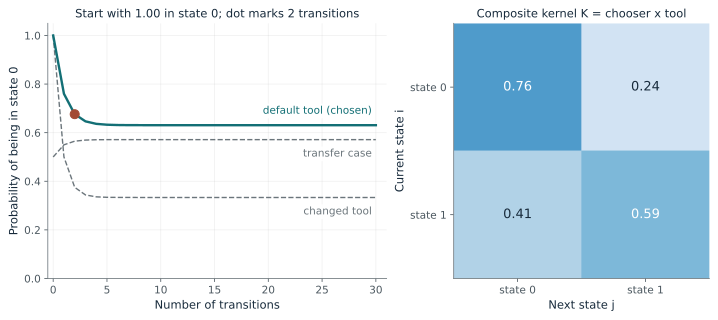

In [11]:
demo_id = 'C05-D02'
demo_controls = {'system': 'default', 'transitions': 2}
demo_result = run_demo(5, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **System** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A fixed chooser, a different tool, a different system
Controls: {"system": "changed", "transitions": 2}
Evidence: constructed teaching example

Calculated quantities:
Composite row 0: [0.50, 0.50]
Composite row 1: [0.25, 0.75]
State 0 after 2 transitions: 0.375
Long-run state 0: 0.333
Chooser rows: [0.80, 0.20] and [0.30, 0.70] (unchanged)

Worked steps:
1. Chooser row 0 = [0.80, 0.20]; tool rows [0.6, 0.4] and [0.1, 0.9].
2. K(0,0) = 0.8 x 0.6 + 0.2 x 0.1 = 0.50 and K(0,1) = 0.8 x 0.4 + 0.2 x 0.9 = 0.50.
3. K(1,0) = 0.3 x 0.6 + 0.7 x 0.1 = 0.25; the second entry of row 1 is 1 - 0.25 = 0.75.
4. After one transition: 1 x 0.50 + 0 x 0.25 = 0.50.
5. After two transitions: 0.50 x 0.50 + 0.50 x 0.25 = 0.375.
6. After 2: 0.375; the long-run share is K(1,0) / (1 - K(0,0) + K(1,0)) = 0.333.

Each row of K mixes the tool's rows, weighted by the chooser's probabilities: K(0,0) = 0.8 x 0.6 + 0.2 x 0.1 = 0.50 and K(0,1) = 0.8 x 0.4 + 0.2 x 0.9 = 0.50; K(1,0) = 0.3 x 0.6 + 0.7 x 0.1 = 0.25. Startin

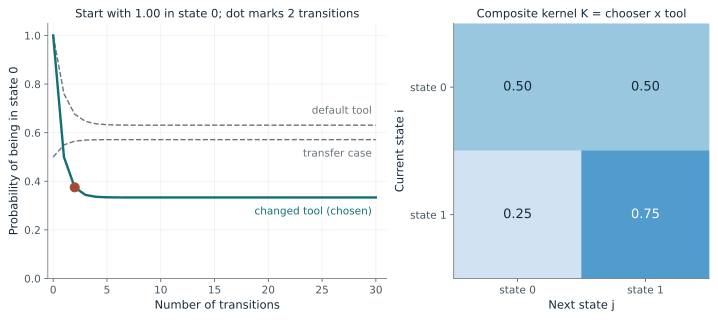

In [12]:
changed_controls = {'system': 'changed', 'transitions': 2}
changed_demo = run_demo(5, 'C05-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(5, 'C05-D02'):
    state = run_demo(5, 'C05-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "system": "default",
      "transitions": 1
    },
    "metrics": [
      [
        "Composite row 0",
        "[0.76, 0.24]"
      ],
      [
        "Composite row 1",
        "[0.41, 0.59]"
      ],
      [
        "State 0 after 1 transition",
        "0.760"
      ],
      [
        "Long-run state 0",
        "0.631"
      ],
      [
        "Chooser rows",
        "[0.80, 0.20] and [0.30, 0.70] (unchanged)"
      ]
    ]
  },
  {
    "controls": {
      "system": "default",
      "transitions": 2
    },
    "metrics": [
      [
        "Composite row 0",
        "[0.76, 0.24]"
      ],
      [
        "Composite row 1",
        "[0.41, 0.59]"
      ],
      [
        "State 0 after 2 transitions",
        "0.676"
      ],
      [
        "Long-run state 0",
        "0.631"
      ],
      [
        "Chooser rows",
        "[0.80, 0.20] and [0.30, 0.70] (unchanged)"
      ]
    ]
  },
  {
    "controls": {
      "system": "default",
      "transitions

**Check your understanding:** With the default tool, what is the chance of state 0 after two transitions when the system starts in state 0?

[Answer and worked reasoning](../solutions/ch05.md#demonstration-2). [Matching browser demonstration](../readers/05-composite-kernel/reader.html#C05-D02).

<a id="demo-c05-d03"></a>

### Demonstration 3: What an observation is worth, and what a memory may drop

How many bits does the tool's report deliver, does delivering them change the outcome, and what happens if the memory drops the report?

![Equation 5.4](../assets/math/94b9a9d7210adada496e.svg)

![Equation 5.3](../assets/math/570697d8140dd69c230d.svg)

**Symbols and units:** Y is the hidden bit and O the tool's report. H(Y) is the uncertainty about Y in bits, 1 bit when both values are equally likely. H(Y | O) is the uncertainty left after seeing O. I(Y;O) is their difference: the bits the report delivers. The accuracy is the chance the report equals Y. Success is the chance of a correct final answer. kappa merges detailed states into abstract classes; dropping the report merges the state 'report says 0' with the state 'report says 1'. Equation (5.3) asks each merged state to send equal probability into every abstract class, here the classes 'answer 0' and 'answer 1'.

With a report that is right with probability a, the posterior on the reported value is a, so H(Y | O) is the entropy of a and I = 1 - H(Y | O). That number depends only on the tool. Whether it matters for the task depends on a different question: does a later choice read it? A memory that keeps the report separates the two states and lets the model answer with it. A memory that drops it merges them, and Equation (5.3) fails because the next answer's chances differ between them, so the connected assembly degrades to the blind second call of row 4.

**Use in this chapter:** For every piece of information a system collects, name the decision it changes. If no decision changes, the collection is decoration, however many bits it carries. Before a summary replaces a record, check that the states it merges send the same probabilities into the same classes.

**Assumptions:** One hidden bit with equal prior, a symmetric tool, and the informed response law held at the book's values for every accuracy. That includes 0.50, where the report carries no information but the declared law still responds to it, because the law is held fixed by construction. Mutual information is symmetric and not causal, and it measures uncertainty removed, not usefulness. Dropping the report entirely is the extreme case of a lossy memory; a partial summary would sit between the two connected rows.

**Predict before running:** At accuracy 0.90, does the information change if the run stops right after the observation? Does the success rate change?

**Controls you can change:**

- **Chance the tool reports the bit correctly:** `accuracy` accepts 0.5, 0.75, 0.9, 1.0.
- **What happens to the report:** `reaches` accepts 'stops', 'dropped', 'reaches'.

**Source section:** What an observation is worth.

**Evidence:** constructed teaching example.

Constructed example: the chapter's tool with accuracy 0.90 (about 0.531 bits) and the blind and informed response laws it declares; other accuracies are values defined for the reader.

Prediction choices:

1. The information stays 0.531 bits and success stays at the model-only 0.300
2. The information stays 0.531 bits and success rises to 0.610
3. The information falls to 0 bits and success stays at 0.300

**Boundary of the conclusion:** Mutual information measures uncertainty reduction, not causation and not usefulness.

**Common wrong turn:** Mutual information measures reduction in uncertainty rather than usefulness: an observation can be highly informative about something the agent has no way to act on, in which case its information value is real and its decision value is zero. It is also symmetric and carries no direction, so it is not a causal statement.

What an observation is worth, and what a memory may drop
Controls: {"accuracy": 0.9, "reaches": "stops"}
Evidence: constructed teaching example

Calculated quantities:
Uncertainty after, H(Y | O): 0.469 bits
Information, I(Y;O): 0.531 bits
Success with this assembly: 0.300
Success gain over model only: 0.000

Worked steps:
1. The tool reports the bit correctly with probability 0.9, so after a report the posterior on the reported value is 0.9.
2. H(Y | O) = 0.1 x 3.322 + 0.9 x 0.152 = 0.469 bits.
3. I(Y;O) = H(Y) - H(Y | O) = 1 - 0.469 = 0.531 bits.
4. The run stops, so no later call reads the report: success = 0.30 + 0.40 x 0 = 0.30.

H(Y | O) = 0.1 x 3.322 + 0.9 x 0.152 = 0.469 bits, so I(Y;O) = 1 - 0.469 = 0.531 bits. The run stops after the observation, so no choice consumes the bits: success = 0.30 + 0.40 x 0 = 0.30, the model-only rate. The information is real and its decision value here is zero.

Assumptions: One hidden bit with equal prior, a symmetric tool, and the informed res

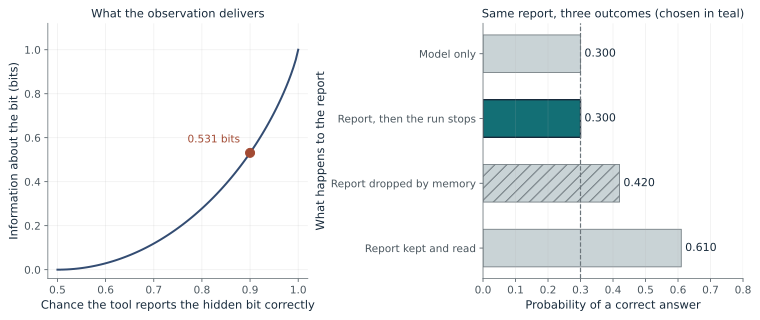

In [14]:
demo_id = 'C05-D03'
demo_controls = {'accuracy': 0.9, 'reaches': 'stops'}
demo_result = run_demo(5, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Chance the tool reports the bit correctly** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

What an observation is worth, and what a memory may drop
Controls: {"accuracy": 0.5, "reaches": "stops"}
Evidence: constructed teaching example

Calculated quantities:
Uncertainty after, H(Y | O): 1.000 bits
Information, I(Y;O): 0.000 bits
Success with this assembly: 0.300
Success gain over model only: 0.000

Worked steps:
1. The tool reports the bit correctly with probability 0.5, so after a report the posterior on the reported value is 0.5.
2. H(Y | O) = 0.5 x 1.000 + 0.5 x 1.000 = 1.000 bits.
3. I(Y;O) = H(Y) - H(Y | O) = 1 - 1.000 = 0.000 bits.
4. The run stops, so no later call reads the report: success = 0.30 + 0.40 x 0 = 0.30.

H(Y | O) = 0.5 x 1.000 + 0.5 x 1.000 = 1.000 bits, so I(Y;O) = 1 - 1.000 = 0.000 bits. The run stops after the observation, so no choice consumes the bits: success = 0.30 + 0.40 x 0 = 0.30, the model-only rate. The report carries no information, so its decision value is zero as well.

Assumptions: One hidden bit with equal prior, a symmetric tool, and the

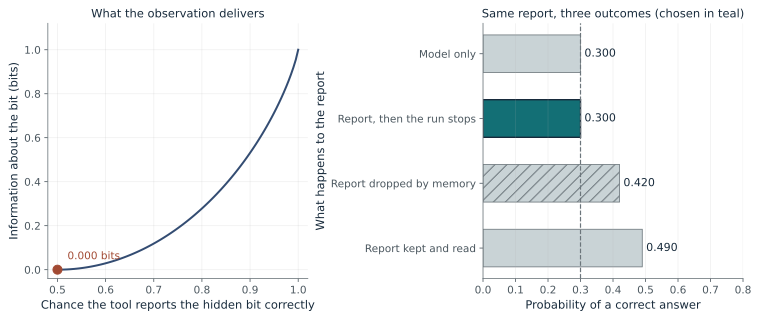

In [15]:
changed_controls = {'accuracy': 0.5, 'reaches': 'stops'}
changed_demo = run_demo(5, 'C05-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(5, 'C05-D03'):
    state = run_demo(5, 'C05-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "accuracy": 0.5,
      "reaches": "stops"
    },
    "metrics": [
      [
        "Uncertainty after, H(Y | O)",
        "1.000 bits"
      ],
      [
        "Information, I(Y;O)",
        "0.000 bits"
      ],
      [
        "Success with this assembly",
        "0.300"
      ],
      [
        "Success gain over model only",
        "0.000"
      ]
    ]
  },
  {
    "controls": {
      "accuracy": 0.5,
      "reaches": "dropped"
    },
    "metrics": [
      [
        "Uncertainty after, H(Y | O)",
        "1.000 bits"
      ],
      [
        "Information, I(Y;O)",
        "0.000 bits"
      ],
      [
        "Success with this assembly",
        "0.420"
      ],
      [
        "Success gain over model only",
        "0.120"
      ]
    ]
  },
  {
    "controls": {
      "accuracy": 0.5,
      "reaches": "reaches"
    },
    "metrics": [
      [
        "Uncertainty after, H(Y | O)",
        "1.000 bits"
      ],
      [
        "Information, I(Y;O

**Check your understanding:** A tool is right with probability 0.75. How many bits does it deliver, and what is H(Y | O)?

[Answer and worked reasoning](../solutions/ch05.md#demonstration-3). [Matching browser demonstration](../readers/05-composite-kernel/reader.html#C05-D03).

<a id="demo-c05-d04"></a>

### Demonstration 4: Recurrence multiplies

If every step is very likely to succeed, how long a task can still survive, and what if the steps share a cause?

![Equation 5.5](../assets/math/4bb12830ba698a772a97.svg)

![Mathematical relation](../assets/demo-equations/4d295ce0d6f01f812ad7.svg)

**Symbols and units:** A run is a sequence of states x_0 to x_T. P(x_{t+1} | x_t) is the probability of one step. Here every required step succeeds with the same conditional probability q given that all earlier steps succeeded, and any unrepaired failure ends the task. With one retry per step, q is the chance that at least one of two independent tries succeeds. With a shared cause, one condition that is good with the marginal probability decides every step together. The half-success horizon is the number of steps n at which q^n = 0.5, n = log 0.5 / log q. The transfer case lists a different conditional rate for each of three steps.

Equation (5.5) says a run's probability is a product of one-step probabilities. With a constant conditional success q, n steps give q multiplied by itself n times, which falls fast even when q is close to 1. A repair step raises q itself, which is why retries and verifiers are the main response to the exponent. A shared cause breaks the product altogether: the marginal rate per step is the same, but the steps are no longer independent, so completion depends on the joint law and not on p.

**Use in this chapter:** Before promising a long unattended task, ask what the per-step success is after the controller's own detection and recovery, not for the model's average accuracy on isolated questions.

**Assumptions:** Constant conditional success and independent retries that use the same budget coordinate (each retry costs budget the chain here does not track). If failures share a cause, such as bad evidence, a retry fails for the same reason and q improves less than shown. The shared-cause line is one constructed joint law with the same marginals, not a model of any real agent. Marginal step accuracies alone do not justify this product.

**Predict before running:** At per-step success 0.95 with no retry, is the chance of finishing 40 steps closer to 0.9, 0.5 or 0.1?

**Controls you can change:**

- **Per-step success:** `case` accepts 'p95', 'p99', 'p999', 'transfer'.
- **How steps relate:** `handling` accepts 'none', 'retry', 'shared'.

**Source section:** Recurrence multiplies.

**Evidence:** constructed teaching example.

Constructed example: the chapter's compounding values (0.99 over 40 steps is 0.669, 0.95 is 0.129) and half-success horizons (about 14, 69 and 693 steps), computed with the laboratory's chain function; the retry rule is a construction defined for the reader, and the transfer case is the notebook's (rates 0.9, 0.8, 0.7).

Prediction choices:

1. Closer to 0.9
2. Closer to 0.5
3. Closer to 0.1

**Boundary of the conclusion:** A task limit derived from this simple chain is a limit of that declared chain, not a universal ceiling on agents.

**Common wrong turn:** You cannot substitute the average accuracy of isolated model answers for the conditional per-step rate: marginal step accuracies alone do not justify the product. Shared bad evidence can make failures cluster, and a verifier or recovery action changes which failures end the task.

Recurrence multiplies
Controls: {"case": "p99", "handling": "none"}
Evidence: constructed teaching example

Calculated quantities:
Conditional success per step used: 0.9900
After 10 steps: 0.904
After 40 steps: 0.669
After 100 steps: 0.366
Steps until success falls below 0.5: 69.0 steps

Worked steps:
1. Any failed step ends the task, so each step must succeed, q = 0.99.
2. Two steps: 0.99 x 0.99 = 0.9801.
3. Forty steps: 0.99^40 = 0.669.
4. Half-success horizon: n = log 0.5 / log 0.99 = 69.0 steps.

Any failed step ends the task, so each step must succeed, q = 0.99. Equation (5.5) multiplies one-step probabilities along the run: two steps give 0.99 x 0.99 = 0.9801, and forty steps give 0.99 x 0.99 x ... x 0.99 (40 factors) = 0.669. The success curve falls below one half after about 69.0 steps, which is n = log 0.5 / log 0.99. This is the limit of this declared chain, not of agents in general.

Assumptions: Constant conditional success and independent retries that use the same budget c

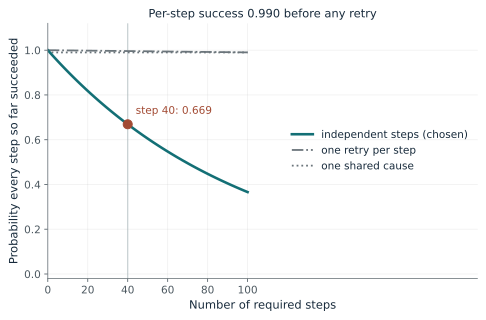

In [17]:
demo_id = 'C05-D04'
demo_controls = {'case': 'p99', 'handling': 'none'}
demo_result = run_demo(5, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Per-step success** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Recurrence multiplies
Controls: {"case": "p95", "handling": "none"}
Evidence: constructed teaching example

Calculated quantities:
Conditional success per step used: 0.9500
After 10 steps: 0.599
After 40 steps: 0.129
After 100 steps: 0.006
Steps until success falls below 0.5: 13.5 steps

Worked steps:
1. Any failed step ends the task, so each step must succeed, q = 0.95.
2. Two steps: 0.95 x 0.95 = 0.9025.
3. Forty steps: 0.95^40 = 0.129.
4. Half-success horizon: n = log 0.5 / log 0.95 = 13.5 steps.

Any failed step ends the task, so each step must succeed, q = 0.95. Equation (5.5) multiplies one-step probabilities along the run: two steps give 0.95 x 0.95 = 0.9025, and forty steps give 0.95 x 0.95 x ... x 0.95 (40 factors) = 0.129. The success curve falls below one half after about 13.5 steps, which is n = log 0.5 / log 0.95. This is the limit of this declared chain, not of agents in general.

Assumptions: Constant conditional success and independent retries that use the same budget c

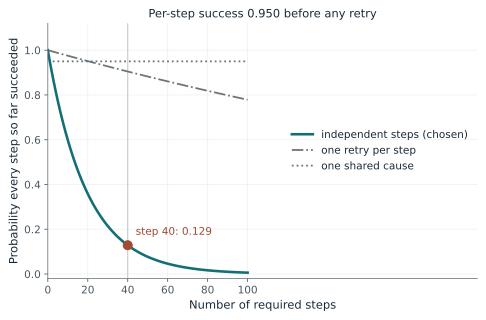

In [18]:
changed_controls = {'case': 'p95', 'handling': 'none'}
changed_demo = run_demo(5, 'C05-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(5, 'C05-D04'):
    state = run_demo(5, 'C05-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "p95",
      "handling": "none"
    },
    "metrics": [
      [
        "Conditional success per step used",
        "0.9500"
      ],
      [
        "After 10 steps",
        "0.599"
      ],
      [
        "After 40 steps",
        "0.129"
      ],
      [
        "After 100 steps",
        "0.006"
      ],
      [
        "Steps until success falls below 0.5",
        "13.5 steps"
      ]
    ]
  },
  {
    "controls": {
      "case": "p95",
      "handling": "retry"
    },
    "metrics": [
      [
        "Conditional success per step used",
        "0.9975"
      ],
      [
        "After 10 steps",
        "0.975"
      ],
      [
        "After 40 steps",
        "0.905"
      ],
      [
        "After 100 steps",
        "0.779"
      ],
      [
        "Steps until success falls below 0.5",
        "277 steps (beyond the plotted 100)"
      ]
    ]
  },
  {
    "controls": {
      "case": "p95",
      "handling": "shared"
    },
    "met

**Check your understanding:** With per-step success 0.90 and one retry per step, what is the chance of finishing 2 steps?

[Answer and worked reasoning](../solutions/ch05.md#demonstration-4). [Matching browser demonstration](../readers/05-composite-kernel/reader.html#C05-D04).

## Questions

1. Compute the default first kernel row.

2. Why can an independent-step model and a shared good-or-bad-condition model both have step marginals p?

3. Compute the transfer conditional product.

Answers: [separate solutions](../solutions/ch05.md). Try the calculation before opening them.

## Summary

An assembled agent has a composite transition kernel. A fixed chooser can behave differently when tool effects change, and recurrence exposes those differences over time. Trajectory reliability depends on joint or conditional structure: equal marginal rates support neither independence nor a universal ceiling. Keep kernel composition, independent construction, shared-condition construction, and chain-rule inputs distinct. The notebook calculates each honestly, while leaving recovery and empirical calibration outside its implemented boundary. The optional factor table holds the chooser fixed while inspecting context transformations and recurrence, and reports allowance and depth comparability explicitly.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-05-composite-kernel`](../skills/maa-05-composite-kernel/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation un-numbered display 1

![Equation un-numbered display 1](../assets/math/788eb3973bb881ecf8ff.svg)



LaTeX source, preserved for inspection:

```latex
0.90(0.85)+0.10(0.10)=0.775.
```

### Equation 5.1

![Equation 5.1](../assets/math/5f46914d9ff9a53d8e15.svg)

Equation (5.1) says the agent's real state is larger than its current prompt, bundling context with retained memory, the world, and the remaining budget.

The state at time $t$ is the four listed coordinates held together: the context, the memory, the world, and the budget.

LaTeX source, preserved for inspection:

```latex
x_t=(c_t,m_t,w_t,b_t).
\tag{5.1}
```

### Equation un-numbered display 3

![Equation un-numbered display 3](../assets/math/58eccb7e6e81e54929b0.svg)



LaTeX source, preserved for inspection:

```latex
\pi_\theta(z,a\mid x)=K_\theta(z\mid c)\operatorname{dec}(a\mid z,c).
```

### Equation 5.2

![Equation 5.2](../assets/math/d730604202b83b1f70fe.svg)

Equation (5.2) defines every coordinate of the next state and separates a controlled transition from the policy that selects proposals.

For a fixed proposal, draw the permission outcome, next world and observation, then the internal update, and average that normalized transition over the model and decoder's proposal law.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
P_{\mathrm{env}}(x'\mid x,u)
 &=\sum_{g,o}\operatorname{Grant}(g\mid x,u)\\
 &\quad\cdot \operatorname{Env}(w',o\mid x,u,g)\\
 &\quad\cdot \operatorname{Upd}(c',m',b'\mid x,u,g,w',o),\\[3pt]
P_\theta(x'\mid x)
 &=\sum_u\pi_\theta(u\mid x)P_{\mathrm{env}}(x'\mid x,u).
\end{aligned}
\tag{5.2}
```

### Equation 5.3

![Equation 5.3](../assets/math/570697d8140dd69c230d.svg)

Equation (5.3) states when merging detailed states preserves the controlled process relevant to action.

From either detailed state, an allowed action must send equal probability into every abstract class.

LaTeX source, preserved for inspection:

```latex
\sum_{y:\kappa(y)=\bar y}P(y\mid x_1,a)
=
\sum_{y:\kappa(y)=\bar y}P(y\mid x_2,a).
\tag{5.3}
```

### Equation 5.4

![Equation 5.4](../assets/math/94b9a9d7210adada496e.svg)

Equation (5.4) measures how much a tool's observation actually reduces uncertainty about the thing the agent needs to know.

Subtract the uncertainty remaining about $Y$ after seeing the observation from the uncertainty before it; what remains is what the observation told you.

LaTeX source, preserved for inspection:

```latex
I(Y;O)=H(Y)-H(Y\mid O).
\tag{5.4}
```

### Equation 5.5

![Equation 5.5](../assets/math/4bb12830ba698a772a97.svg)

Equation (5.5) says a whole run's probability is a product of one-step probabilities, so recurrence multiplies rather than adds.

Start from the initial state and multiply the one-step transition probabilities along the run.

LaTeX source, preserved for inspection:

```latex
\Pr(x_{0:T})=\Pr(x_0)\prod_{t=0}^{T-1}P(x_{t+1}\mid x_t).
\tag{5.5}
```